In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# reproducibility — the training task now involves real conditional logic
# (not just re-adding pre-computed scores), so results vary run-to-run
# without a fixed seed. Pin everything so results are reproducible.
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


df = pd.read_csv('../data/plants_final.csv')
print(f"Loaded: {df.shape}")
print(f"\nScore columns check:")
score_cols = ['beginner_score', 'drought_score', 'climate_score',
              'space_score', 'edibility_score', 'safety_score', 'overall_home_score']
print(df[score_cols].describe().round(2))

Loaded: (936, 70)

Score columns check:
       beginner_score  drought_score  climate_score  space_score  \
count          936.00         936.00         936.00       936.00   
mean            73.76          51.46          47.03        29.52   
std             10.08          26.35          27.09        34.52   
min             45.00           3.57           0.00         0.00   
25%             66.67          30.00          15.00         0.00   
50%             75.00          52.14          40.00        12.50   
75%             81.67          72.14          70.00        53.50   
max            100.00         100.00         100.00       100.00   

       edibility_score  safety_score  overall_home_score  
count           936.00        936.00              936.00  
mean             22.09         94.25               53.47  
std              30.55         17.08               15.01  
min               0.00          0.00               19.81  
25%               0.00        100.00               3

### feature prep, encoding and scaling

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import os

df = pd.read_csv('../data/plants_final.csv')
print(f"Loaded: {df.shape}")

cat_cols = ['watering', 'sunlight_primary', 'care_level',
            'maintenance', 'growth_rate', 'cycle', 'type', 'size_category']

num_cols = [
    'hardiness_min', 'hardiness_max',
    'height_min_feet', 'height_max_feet',
    'watering_days'
]

# boolean — already 0/1
# NOTE: is_low_maintenance, is_beginner_friendly, is_drought_resistant, and
# is_indoor_suitable are excluded below — they are literal thresholds of
# beginner_score / drought_score / space_score (e.g. is_beginner_friendly =
# beginner_score >= 80), so keeping them would leak the target through the
# back door even after removing the score columns themselves.
bool_cols = [
    'indoor', 'tropical', 'drought_tolerant', 'thorny',
    'invasive', 'flowers', 'fruits', 'edible_fruit',
    'leaf', 'edible_leaf', 'cuisine', 'medicinal',
    'poisonous_to_humans', 'poisonous_to_pets',
    'is_edible', 'is_pet_safe', 'is_child_safe', 'is_family_safe',
    'is_fast_growing', 'is_flowering', 'is_medicinal', 'is_culinary',
    'is_climate_match', 'is_small_space',
    'is_perennial', 'is_annual', 'is_year_round',
    'has_image', 'has_companion_data'
]

# engineered scores 0-100
# NOTE: beginner_score, drought_score, climate_score, space_score,
# edibility_score, safety_score are excluded — overall_home_score (the
# target) is literally a fixed weighted sum of exactly these six
# (0.25/0.25/0.20/0.15/0.10/0.05), so including them let the network
# shortcut straight to the answer instead of learning it from raw
# plant attributes. attention_score/low_attention_score/data_quality_score
# are NOT part of that formula, so they're safe to keep.
score_features = [
    'attention_score', 'low_attention_score', 'data_quality_score'
]

extra_cols = ['israel_zone_match']
target_cols = ['overall_home_score']

# encode categoricals
df_model = df.copy()
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f"{col}: {len(le.classes_)} classes")

encoded_cols = [col + '_enc' for col in cat_cols]

# build feature matrix
feature_cols = encoded_cols + num_cols + bool_cols + score_features + extra_cols
df_model[feature_cols] = df_model[feature_cols].fillna(0)

X = df_model[feature_cols].values.astype(np.float32)
y = df_model[target_cols].values.astype(np.float32)

print(f"\nX: {X.shape} — {X.shape[1]} features")
print(f"y: {y.shape} — target range {y.min():.1f} to {y.max():.1f}")

# scale numericals
scaler = StandardScaler()
num_indices = [feature_cols.index(col) for col in num_cols]
X[:, num_indices] = scaler.fit_transform(X[:, num_indices])

# split — 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\ntrain: {X_train.shape[0]} | val: {X_val.shape[0]} | test: {X_test.shape[0]}")

# save preprocessing
os.makedirs('../models', exist_ok=True)

with open('../models/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print("saved: encoders.pkl, scaler.pkl, feature_cols.pkl")
print(f"\n{len(feature_cols)} features ready")

Loaded: (936, 70)
watering: 3 classes
sunlight_primary: 3 classes
care_level: 3 classes
maintenance: 3 classes
growth_rate: 3 classes
cycle: 4 classes
type: 15 classes
size_category: 5 classes

X: (936, 46) — 46 features
y: (936, 1) — target range 19.8 to 89.8

train: 655 | val: 140 | test: 141
saved: encoders.pkl, scaler.pkl, feature_cols.pkl

46 features ready


### Neural Network Training

In [5]:
def build_matcher_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        # First layer captures broad feature relationships
        Dense(256, activation='relu'),
        BatchNormalization(),  
        Dropout(0.3),

        # Second layer compressing
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        # Third layer more compression
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        # Fourth layer final feature compression
        Dense(32, activation='relu'),
        Dropout(0.1),

        # Predicts the overall_home_score as a continuous number
        Dense(1)
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',        # mean squared error for regression
        metrics=['mae']    # mean absolute error (easier to interpret)
    
    )
    
    return model

model = build_matcher_model(input_dim=X_train.shape[1])
model.summary()


callbacks = [
    # Stop training when  val_loss stops improving
    # restore_best_weights loads best epoch automatically
    EarlyStopping(
        monitor='val_loss',
        patience=25,  # raised from 15 — the leak-free task needs more room to converge
        restore_best_weights=True,
        verbose=1
    ),
    
    # Saves best model to disk whenever val_loss improves
    ModelCheckpoint(
        filepath='../models/matcher_model_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    
    # Reduces learning rate when training plateaus
    # If val_loss doesn't improve for 7 epochs, multiply lr by 0.5
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=0.00001,
        verbose=1
    )
]

print("\nStarting training...")
print(f"Training on {X_train.shape[0]} plants")
print(f"Validating on {X_val.shape[0]} plants")
print(f"Max epochs: 150 (early stopping will likely trigger before this)\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print(f"\nTraining complete.")
print(f"Best epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")
print(f"Best val_mae: {min(history.history['val_mae']):.4f}")




Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)         

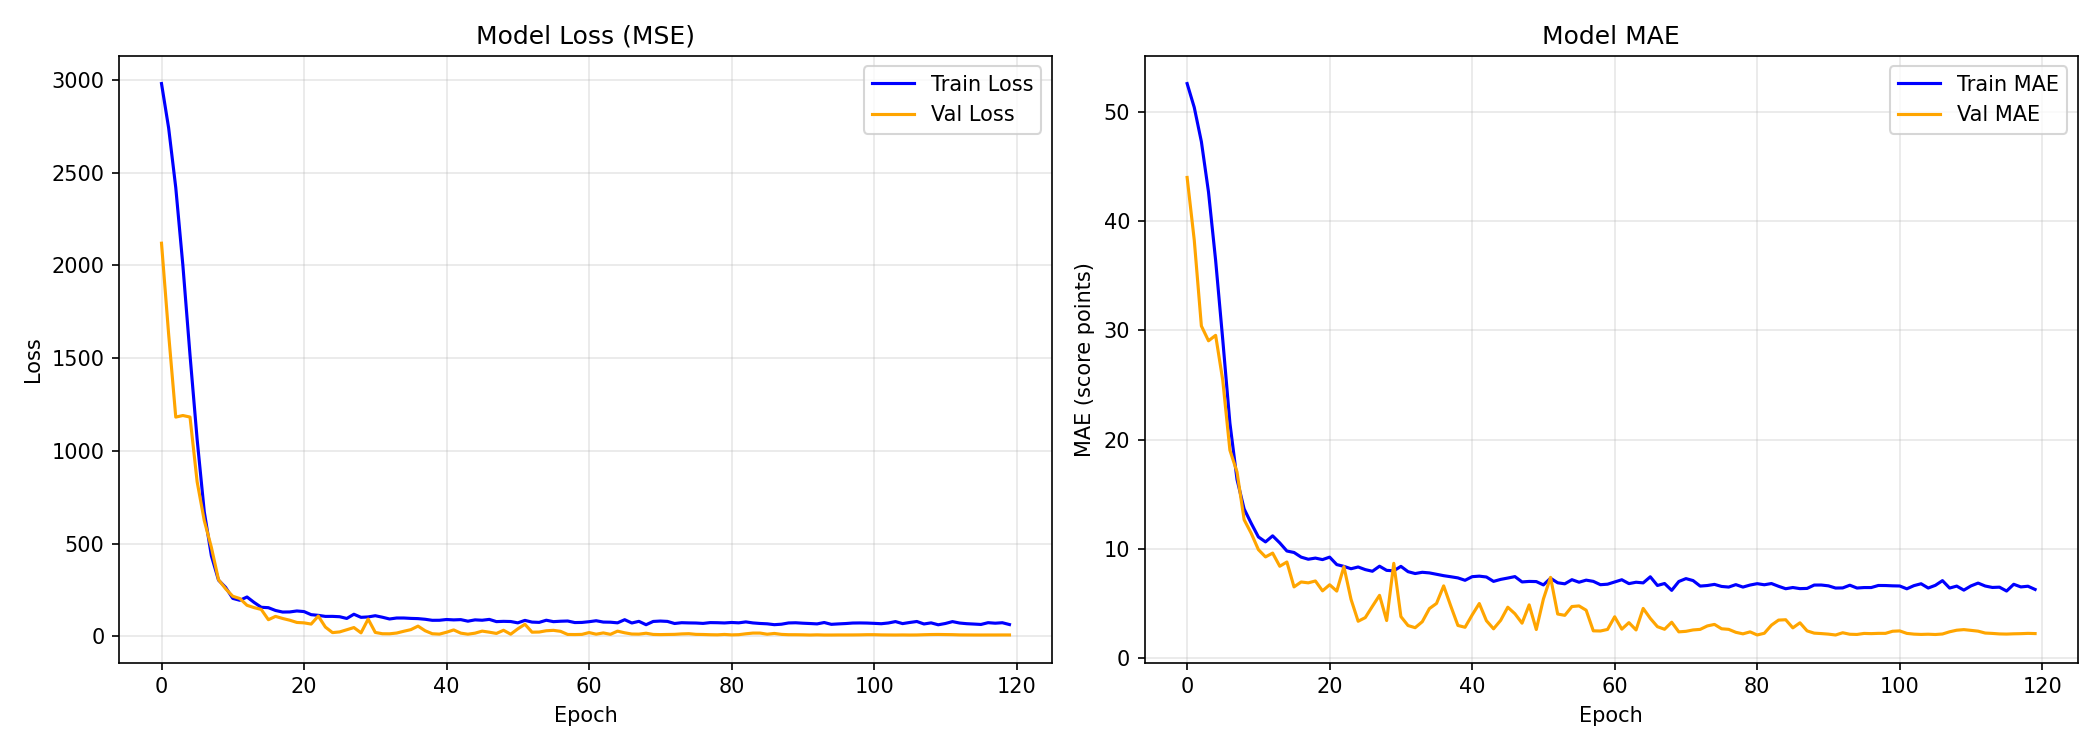

Training history plot saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Model Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Train MAE', color='blue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='orange')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (score points)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/training_history.png', dpi=150)
plt.show()
print("Training history plot saved.")

### eval

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:

best_model = tf.keras.models.load_model('../models/matcher_model_best.keras')

y_pred = best_model.predict(X_test).flatten()
y_true = y_test.flatten()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)


print("Test Eval — Unseen Data")
print(f"MAE:  {mae:.4f} score points (avg error)")
print(f"RMSE: {rmse:.4f} score points")
print(f"R2:   {r2:.4f}")
print(f"-------")
print(f"Model is off by {mae:.1f} score points on average")
print(f"Target range span: 70 points")
print(f"Error as % of range: {mae/70*100:.1f}%")




1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

=== Test Eval — Unseen Data (PRODUCTION, LEAK-FREE MODEL) ===
MAE:  2.3225 score points
RMSE: 2.9273 score points
R2:   0.9624
Error as % of 70-point range: 3.3%


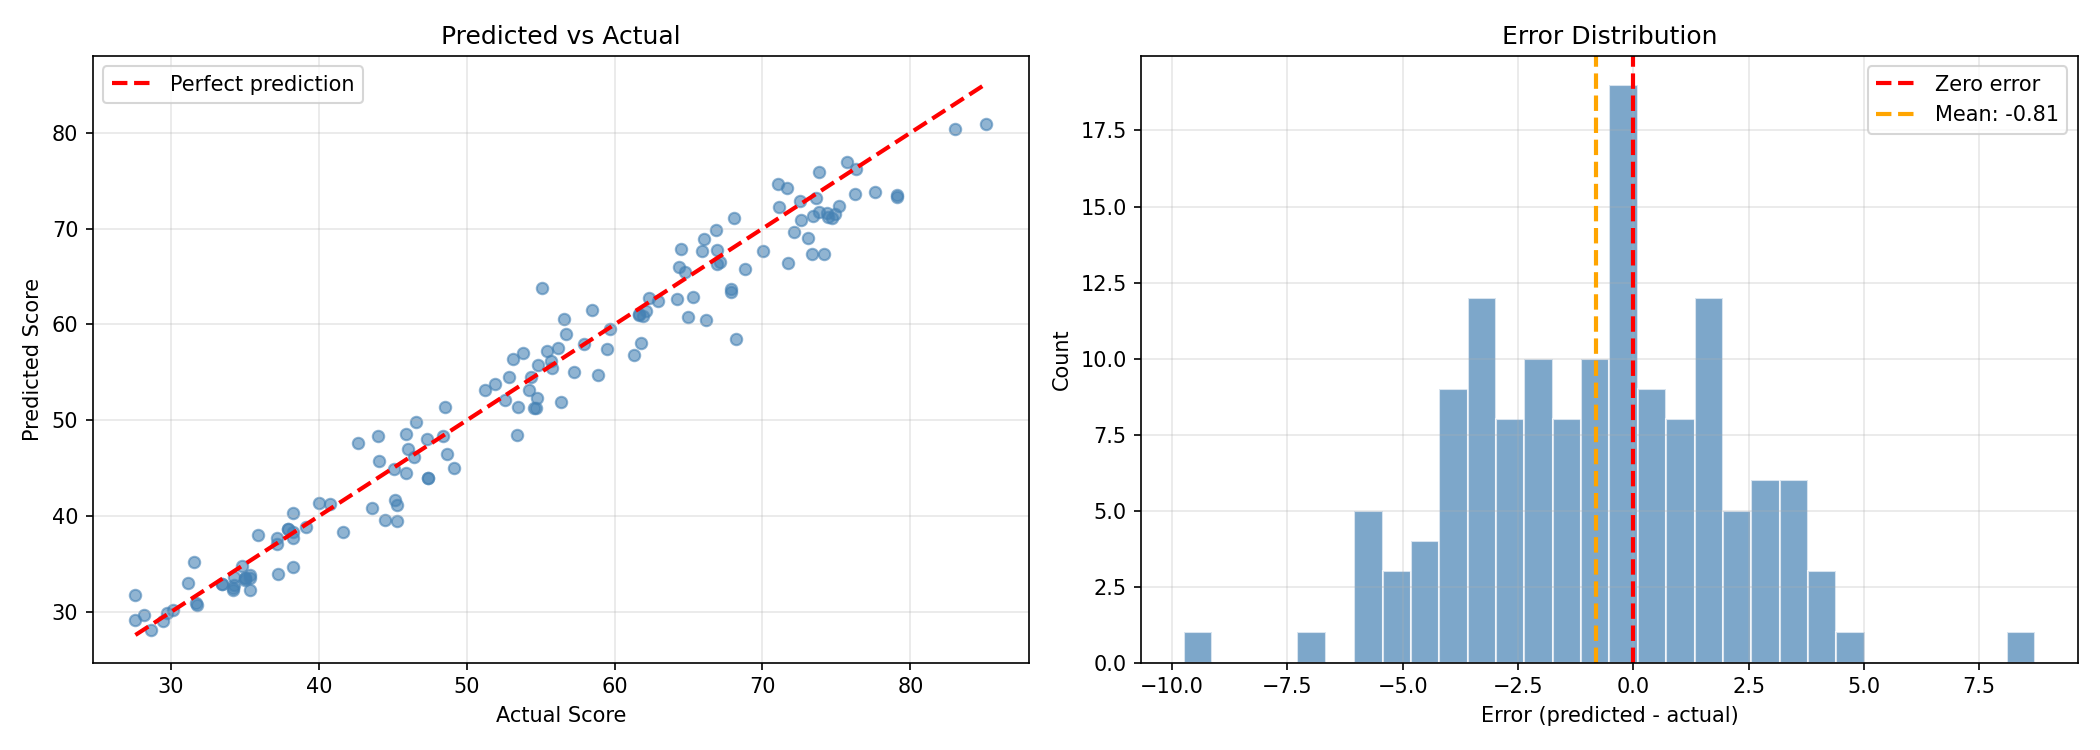

Final model saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_true, y_pred, alpha=0.6, color='steelblue', s=30)
axes[0].plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = y_pred - y_true
axes[1].hist(errors, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[1].axvline(errors.mean(), color='orange', linestyle='--',
                linewidth=2, label=f'Mean: {errors.mean():.2f}')
axes[1].set_xlabel('Error (predicted - actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/evaluation_plots.png', dpi=150)
plt.show()

best_model.save('../models/matcher_model_final.keras')
print("Final model saved.")